# K-Means Clustering from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

**K-Means** is an unsupervised clustering algorithm that partitions data into **k clusters** by iteratively assigning points to the nearest centroid and updating centroids to the mean of assigned points.

The algorithm minimizes the **within-cluster sum of squares (inertia)**:

$$J = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

The algorithm follows these steps:

1. Initialize k centroids randomly from the data points
2. Assign each point to its nearest centroid
3. Update each centroid to the mean of its assigned points
4. Repeat steps 2 and 3 until convergence

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split as sklearn_split

from rice_ml.unsupervised_learning.k_means import KMeans
from rice_ml.processing.preprocessing import StandardScaler

## Generating the Dataset

We use **make_blobs** to generate a synthetic dataset with well-separated clusters. This is the standard benchmark for clustering algorithms.

Dataset shape: (300, 2)
True number of clusters: 4


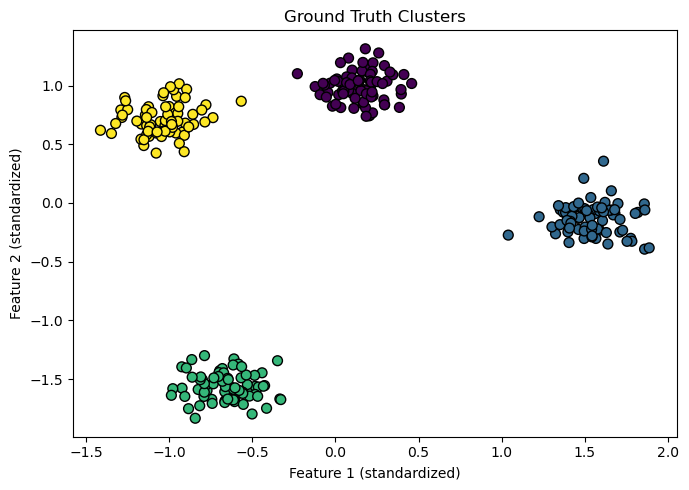

In [2]:
X, y_true = make_blobs(n_samples=300, centers=4,
                        cluster_std=0.8, random_state=42)

scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

print(f"Dataset shape: {X_scaled.shape}")
print(f"True number of clusters: {len(np.unique(y_true))}")

plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true,
            cmap='viridis', edgecolors='k', s=50)
plt.title('Ground Truth Clusters')
plt.xlabel('Feature 1 (standardized)')
plt.ylabel('Feature 2 (standardized)')
plt.tight_layout()
plt.show()

## Training K-Means

In [3]:
model = KMeans(k=4, random_state=42)
model.fit(X_scaled)

print(f"Cluster assignments: {np.bincount(model.labels_)}")
print(f"Inertia: {model.inertia(X_scaled):.4f}")

Cluster assignments: [75 75 75 75]
Inertia: 11.3170


## Visualizing Cluster Assignments vs Ground Truth

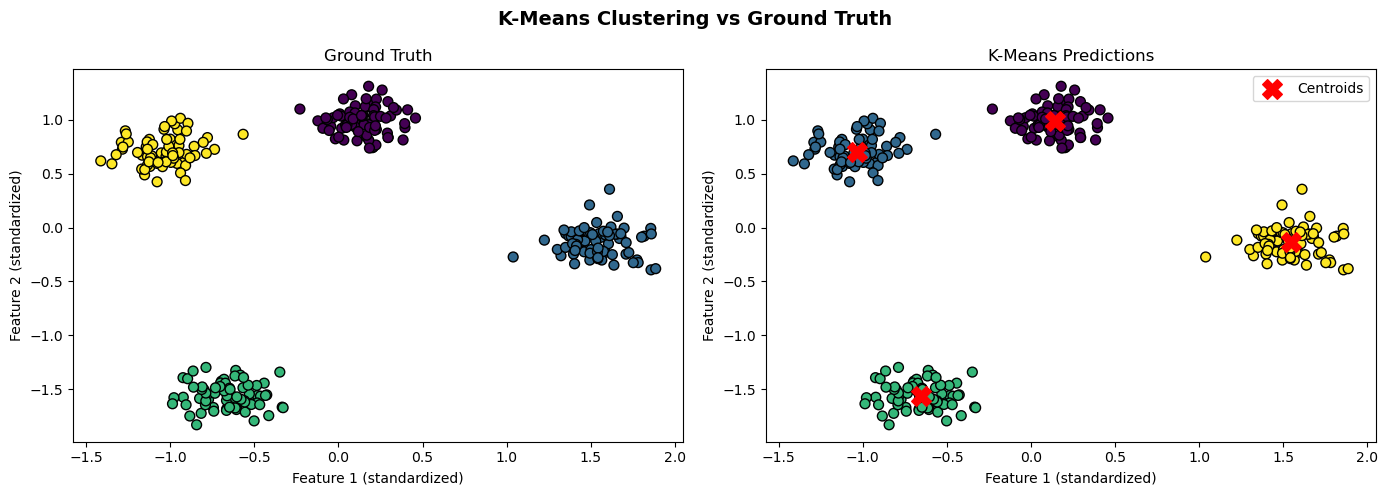

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true,
                cmap='viridis', edgecolors='k', s=50)
axes[0].set_title('Ground Truth')
axes[0].set_xlabel('Feature 1 (standardized)')
axes[0].set_ylabel('Feature 2 (standardized)')

axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=model.labels_,
                cmap='viridis', edgecolors='k', s=50)
axes[1].scatter(model.centroids[:, 0], model.centroids[:, 1],
                c='red', marker='X', s=200, zorder=5, label='Centroids')
axes[1].set_title('K-Means Predictions')
axes[1].set_xlabel('Feature 1 (standardized)')
axes[1].set_ylabel('Feature 2 (standardized)')
axes[1].legend()

plt.suptitle('K-Means Clustering vs Ground Truth',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Finding the Optimal k with the Elbow Method

We do not always know the right number of clusters in advance. The **elbow method** plots inertia vs k and looks for the point where adding more clusters gives diminishing returns.

In [5]:
k_values = range(1, 10)
inertias = []

for k in k_values:
    m = KMeans(k=k, random_state=42).fit(X_scaled)
    inertias.append(m.inertia(X_scaled))
    print(f"k = {k} | Inertia = {inertias[-1]:.4f}")

k = 1 | Inertia = 600.0000
k = 2 | Inertia = 330.2760
k = 3 | Inertia = 66.7045
k = 4 | Inertia = 11.3170
k = 5 | Inertia = 10.1517
k = 6 | Inertia = 9.8338
k = 7 | Inertia = 8.4612
k = 8 | Inertia = 9.1875
k = 9 | Inertia = 8.1661


## Visualizing the Elbow Curve

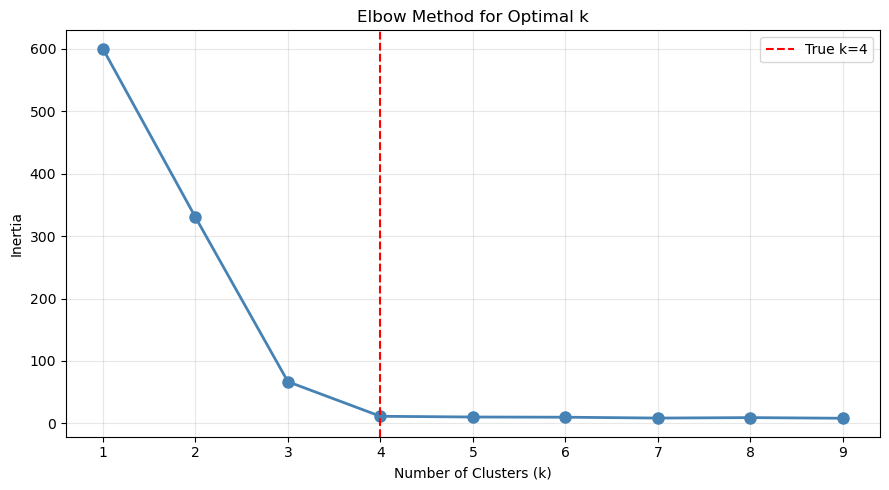

In [6]:
plt.figure(figsize=(9, 5))
plt.plot(k_values, inertias, marker='o', linewidth=2,
         markersize=8, color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.axvline(x=4, color='red', linestyle='--', label='True k=4')
plt.legend()
plt.tight_layout()
plt.show()

## Effect of Different k Values

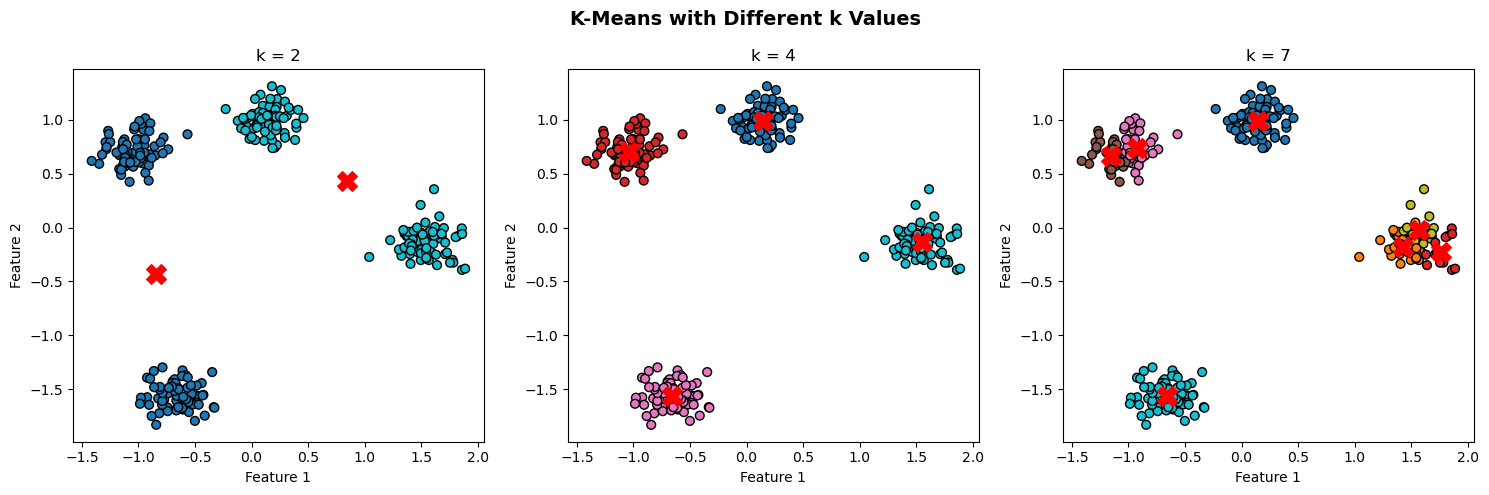

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
k_vals = [2, 4, 7]

for ax, k in zip(axes, k_vals):
    m = KMeans(k=k, random_state=42).fit(X_scaled)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=m.labels_,
               cmap='tab10', edgecolors='k', s=40)
    ax.scatter(m.centroids[:, 0], m.centroids[:, 1],
               c='red', marker='X', s=200, zorder=5)
    ax.set_title(f'k = {k}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('K-Means with Different k Values',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Discussion

- K-Means successfully identifies all 4 clusters in the synthetic dataset, with perfectly balanced assignments of 75 points per cluster and an inertia of 11.3170
- The **ground truth vs predictions plot** shows near-perfect agreement between the true cluster labels and K-Means assignments, with the 4 red centroids positioned at the center of each cluster
- The **elbow curve** clearly shows a sharp drop in inertia from k=1 to k=4, after which the curve flattens significantly, confirming that k=4 is the optimal number of clusters for this dataset
- The elbow at k=4 aligns perfectly with the true number of clusters used to generate the data, demonstrating that the elbow method is an effective tool for selecting k
- The **different k values plot** illustrates what happens when k is misspecified
- At k=2, the algorithm merges distinct clusters together, losing important structure in the data
- At k=4, the algorithm correctly recovers the true cluster structure
- At k=7, the algorithm over-partitions the data, splitting natural clusters into smaller artificial ones
- K-Means works well here because the clusters are roughly spherical, equally sized, and well-separated, which matches the algorithm's core assumptions
- **Strengths** include simplicity, scalability to large datasets, and effectiveness on well-separated spherical clusters
- **Weaknesses** include sensitivity to the choice of k, sensitivity to initial centroid placement, poor performance on non-spherical or unequally sized clusters, and inability to handle noise or outliers
- These weaknesses motivate density-based methods like DBSCAN, which can discover clusters of arbitrary shape and automatically handle noise